# Fine-Tuning Vision Transformers for Image Classification

In [1]:
%%capture
! pip install datasets transformers

## Load a dataset

In [ ]:
from huggingface_hub import login
import os
login(os.getenv("HF_TOKEN"))

In [3]:
from datasets import load_dataset

ds = load_dataset('ikram98ai/compliance_verification')
ds

README.md:   0%|          | 0.00/469 [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/995k [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/248k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15587 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3897 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image_urls', 'compliance_status', 'violation_reason'],
        num_rows: 15587
    })
    test: Dataset({
        features: ['image_urls', 'compliance_status', 'violation_reason'],
        num_rows: 3897
    })
})

In [4]:
ex = ds['train'][2]
ex

{'image_urls': ['https://cf.freshprints.com/designs/1694998809572oaoms_nt_front.png',
  'https://cf.freshprints.com/designs/1694998809572abohc_nt_back.png'],
 'compliance_status': 'Non-compliant',
 'violation_reason': 'This design is rejected. Needs to be all 3 greek letters.We welcome you to modify and resubmit the design for further review.'}

Let's take a look at the image 👀

In [5]:
image_urls = ex['image_urls']
image_urls

['https://cf.freshprints.com/designs/1694998809572oaoms_nt_front.png',
 'https://cf.freshprints.com/designs/1694998809572abohc_nt_back.png']

In [6]:
ex['compliance_status']

'Non-compliant'

## Loading ViT Feature Extractor

In [7]:
from transformers import ViTImageProcessor

model_name_or_path = 'google/vit-base-patch16-224-in21k'
feature_extractor = ViTImageProcessor.from_pretrained(model_name_or_path)

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

If we print a feature extractor, we can see its configuration.

In [8]:
feature_extractor

ViTImageProcessor {
  "do_convert_rgb": null,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}

To process an image, simply pass it to the feature extractor's call function. This will return a dict containing `pixel values`, which is the numeric representation of your image that we'll pass to the model.

We get a numpy array by default, but if we add the `return_tensors='pt'` argument, we'll get back `torch` tensors instead.


In [9]:
import requests
from PIL import Image as PILImage
from io import BytesIO

def load_image_from_url(url):
    """Helper function to download and convert image from URL"""
    try:
        response = requests.get(url, stream=True, timeout=10)
        response.raise_for_status()
        return PILImage.open(BytesIO(response.content)).convert("RGB")
    except Exception as e:
        print(f"Error loading image from {url}: {str(e)}")
        return None

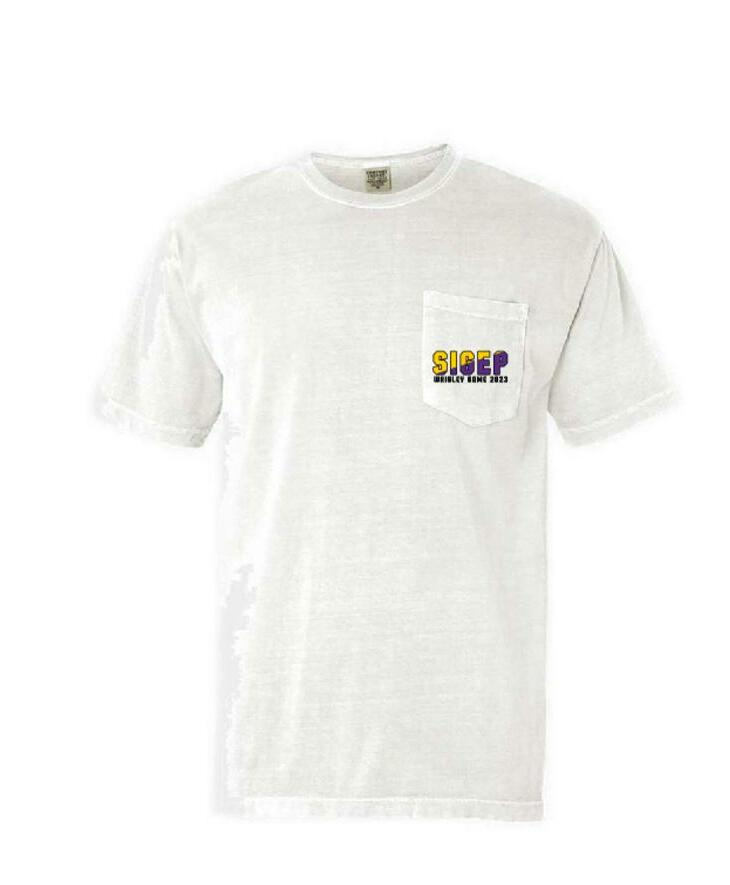

In [10]:
load_image_from_url(image_urls[0])

## Processing the Dataset

In [12]:
def process_example(example):
    inputs = feature_extractor(load_image_from_url(example['image_urls'][0]), return_tensors='pt')
    inputs['labels'] = example['compliance_status']
    return inputs

In [13]:
process_example(ds['train'][0])

{'pixel_values': tensor([[[[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]],

         [[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]],

         [[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]]]]), 'labels': 'Non-compliant'}

While we could call `ds.map` and apply this to every example at once, this can be very slow, especially if you use a larger dataset. Instead, we'll apply a ***transform*** to the dataset. Transforms are only applied to examples as you index them.

First, though, we'll need to update our last function to accept a batch of data, as that's what `ds.with_transform` expects.

In [41]:
label2id = {
    'Compliant': 0,
    'Non-compliant': 1
}

def transform(example_batch):
    # print('Example Batch:: ', example_batch)
    # Take a list of PIL images and turn them to pixel values
    inputs = feature_extractor([load_image_from_url(x[0]) for x in example_batch['image_urls']], return_tensors='pt')
      # Convert string labels to numerical labels
    # Update the 'labels' key with numerical values using label2id mapping.
    inputs['labels'] = [label2id[x] for x in example_batch['compliance_status']]

    return inputs

prepared_ds = ds.with_transform(transform)

We can directly apply this to our dataset using `ds.with_transform(transform)`.

In [35]:
prepared_ds = ds.with_transform(transform)

# Training and Evaluation

The data is processed and we are ready to start setting up the training pipeline. We will make use of 🤗's Trainer, but that'll require us to do a few things first:

- Define a collate function.

- Define an evaluation metric. During training, the model should be evaluated on its prediction accuracy. We should define a compute_metrics function accordingly.

- Load a pretrained checkpoint. We need to load a pretrained checkpoint and configure it correctly for training.

- Define the training configuration.

After having fine-tuned the model, we will correctly evaluate it on the evaluation data and verify that it has indeed learned to correctly classify our images.

### Define our data collator

Batches are coming in as lists of dicts, so we just unpack + stack those into batch tensors.

We return a batch `dict` from our `collate_fn` so we can simply `**unpack` the inputs to our model later. ✨

In [37]:
import torch

def collate_fn(batch):
    return {
        'pixel_values': torch.stack([x['pixel_values'] for x in batch]),
        'labels': torch.tensor([x['labels'] for x in batch])
    }

### Define an evaluation metric

Here, we load the [accuracy](https://huggingface.co/metrics/accuracy) metric from `datasets`, and then write a function that takes in a model prediction + computes the accuracy.

In [38]:
%%capture
!pip install evaluate==0.4.0

In [39]:
import numpy as np
from evaluate import load

metric = load("accuracy")
def compute_metrics(p):
    return metric.compute(predictions=np.argmax(p.predictions, axis=1), references=p.label_ids)

Now we can load our pretrained model. We'll add `num_labels` on init to make sure the model creates a classification head with the right number of units. We'll also include the `id2label` and `label2id` mappings so we have human readable labels in the 🤗 hub widget if we choose to `push_to_hub`.

In [27]:
ds['train'].features['compliance_status']

Value(dtype='string', id=None)

In [42]:
label2id

{'Compliant': 0, 'Non-compliant': 1}

In [43]:
from transformers import ViTForImageClassification

labels = ['Compliant','Non-compliant'] # ds['train'].features['compliance_status'].names

model = ViTForImageClassification.from_pretrained(
    model_name_or_path,
    num_labels=len(labels),
    id2label= {v:k for k, v in label2id.items()},
    label2id= label2id,
)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


We're almost ready to train! The last thing we'll do before that is set up the training configuration by defining [`TrainingArguments`](https://huggingface.co/docs/transformers/v4.16.2/en/main_classes/trainer#transformers.TrainingArguments).

Most of these are pretty self-explanatory, but one that is quite important here is `remove_unused_columns=False`. This one will drop any features not used by the model's call function. By default it's `True` because usually its ideal to drop unused feature columns, as it makes it easier to unpack inputs into the model's call function. But, in our case, we need the unused features ('image' in particular) in order to create 'pixel_values'.

What I'm trying to say is that you'll have a bad time if you forget to set `remove_unused_columns=False`.

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
  output_dir="./vit-base-beans-demo-v5",
  per_device_train_batch_size=16,
  num_train_epochs=4,
  fp16=True,
  save_steps=100,
  eval_strategy="steps",
  eval_steps=100,
  logging_steps=10,
  learning_rate=2e-4,
  save_total_limit=2,
  remove_unused_columns=False,
  push_to_hub=False,
  report_to='none',
  load_best_model_at_end=True,
)

Now, all instances can be passed to Trainer and we are ready to start training!



In [45]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    train_dataset=prepared_ds["train"],
    eval_dataset=prepared_ds["test"],
    tokenizer=feature_extractor,
)

<ipython-input-45-ed228724e133>:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
train_results = trainer.train()
trainer.save_model()
trainer.log_metrics("train", train_results.metrics)
trainer.save_metrics("train", train_results.metrics)
trainer.save_state()

Step,Training Loss,Validation Loss


In [ ]:
metrics = trainer.evaluate(prepared_ds['validation'])
trainer.log_metrics("eval", metrics)
trainer.save_metrics("eval", metrics)

***** Running Evaluation *****
  Num examples = 133
  Batch size = 8


***** eval metrics *****
  epoch                   =        4.0
  eval_accuracy           =      0.985
  eval_loss               =     0.0637
  eval_runtime            = 0:00:02.13
  eval_samples_per_second =     62.356
  eval_steps_per_second   =       7.97


In [ ]:
kwargs = {
    "finetuned_from": model.config._name_or_path,
    "tasks": "image-classification",
    "dataset": 'beans',
    "tags": ['image-classification'],
}

if training_args.push_to_hub:
    trainer.push_to_hub('🍻 cheers', **kwargs)
else:
    trainer.create_model_card(**kwargs)

The resulting model has been shared to [nateraw/vit-base-beans](https://huggingface.co/nateraw/vit-base-beans). I'm assuming you don't have pictures of bean leaves laying around, but if you do, you can try out the model in the browser 🚀.